# <center> LINMA2474 - Project 1 : Graph learning and image inpainting with Riemannian optimization</center>

#### <center>27-02-2026 V1</center>


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

import torch
import pymanopt
from pymanopt.manifolds import Sphere, FixedRankEmbedded
from pymanopt.optimizers import SteepestDescent, TrustRegions

## Write your additional imports here

In [8]:
np.random.seed(42)
torch.random.manual_seed(42);

## 1. CIFAR-10 dataset

In [9]:
## Do not modify ##
channels = 3
p = 32
n = p*p

N_part1 = 200
N_part2 = 32
N_green_frog = N_part1+N_part2

N_class  = 5000
N_batch  = 10000
N_test   = 10000
N_sample = 50000
## ############# ##


channel_idx = {
    'R' : 0,
    'G' : 1,
    'B' : 2,
}

#### 1.1 Load data

In [10]:
## Load Dataset ##
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def extract_data_and_swap_axes(dataset):
    data = dataset[b'data'].reshape((N_batch, 3, p, p))
    labels = dataset[b'labels']
    data = np.swapaxes(data, 1, 3)
    data = np.swapaxes(data, 1, 2)
    return data, labels

list_batches = []
list_labels = []
for i in range(5):
    dataset = unpickle(f"cifar-10-batches-py/data_batch_{i+1}")
    dataset, labels = extract_data_and_swap_axes(dataset)
    list_batches.append(dataset)
    list_labels.append(labels)

/tmp/ipykernel_12098/2943447391.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


#### 1.2 Normalize and sample green frogs

In [11]:
## ############# ##
## Do not modify ##
## ############# ##

batches = np.array(list_batches).reshape(N_sample, n*channels) / 255
labels = np.array(list_labels).reshape(N_sample,)
frog_images = torch.from_numpy(batches[labels == 6])

# Select Green Frogs
green_frogs = []

for img in frog_images:
    r_mean = img[0].mean().item()
    g_mean = img[1].mean().item()
    b_mean = img[2].mean().item()

    if g_mean > 1.5 * r_mean and g_mean > 1.5 * b_mean:
        green_frogs.append(img)

green_frogs = torch.stack(green_frogs)

print("Total green frogs:", green_frogs.shape[0])

green_frogs = green_frogs.reshape(N_green_frog, n*channels).T.reshape(n, channels, N_green_frog).numpy()
data_part1 = green_frogs[..., :N_part1]
data_part2 = green_frogs[..., N_part1:]

## ############# ##
## ############# ##
## ############# ##

print(data_part1.shape)
print(data_part2.shape)

Total green frogs: 232
(1024, 3, 200)
(1024, 3, 32)


#### 1.3 Corrupt green frogs of dataset 2

In [12]:
def corrupt_image(img):
    # Generate random mask (20% missing pixels)
    missing_ratio = 0.2
    mask = np.random.rand(n) > missing_ratio 
    mask = np.repeat(mask[:, None], channels, axis=1)

    # Apply forward inpainting operator
    corrupted_img = img * mask
    return corrupted_img, mask

In [13]:
corrupted_data = np.zeros((n, channels, N_part2))
mask_lst = np.zeros((n, channels, N_part2))
for i in range(N_part2):
    y, mask = corrupt_image(data_part2[:,:,i])
    corrupted_data[:,:,i] = y 
    mask_lst[:,:,i] = mask

#### 1.4 Show samples

In [14]:
def show_samples_image(X, p=32, grid_dim=6, title="", width=1.2, height=1.2, SNR_labels=None, channels=channels, N_samples=N_part1, savefig=None, vmin=0, vmax=1):
    """
    Show samples of a dataset X of p x p images.
    @args:
        <numpy array> X: dataset.
        <int> p: dimension of an image.
        <int> grid_dim: dimension of the grid of displayed samples.
        <string> title: title of the grid.
    """
    Y = X.reshape(p, p, channels, N_samples).clip(0,1) 
    fig, axes = plt.subplots(grid_dim,grid_dim)
    fig.suptitle(title)
    fig.set_figheight(grid_dim*width)
    fig.set_figwidth(grid_dim*height)
    #Y = Y - Y.min()
    #Y = Y / Y.max()
    for i in range(grid_dim):
        for j in range(grid_dim):
            axes[i,j].imshow(Y[:,:,:,grid_dim*i+j], vmin=vmin, vmax=vmax)
            axes[i,j].axis("off")
            if SNR_labels is not None:
                axes[i,j].set_title("%.2f" % SNR_labels[grid_dim*i+j])
    
    if savefig is not None:
        plt.savefig(savefig+".pdf", bbox_inches="tight")
    plt.show()

def show_image(x, p=32):
    """
    Show a p x p image.
    @args:
        <numpy array> x: image.
        <int> p: dimension of the image.
    """
    y = (x).reshape(p, p, 3) 
    y = y - y.min()
    y = y / y.max()
    plt.figure(figsize=(1,1))
    plt.imshow(y)
    plt.axis("off")
    plt.show()

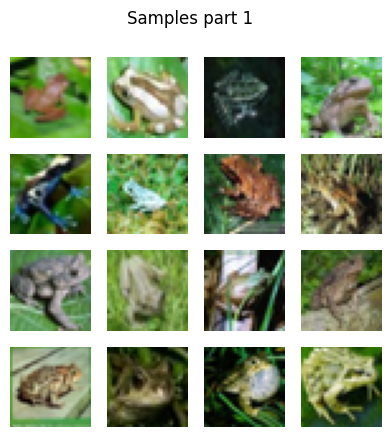

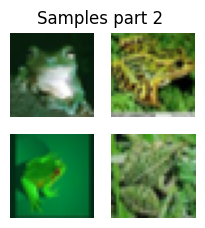

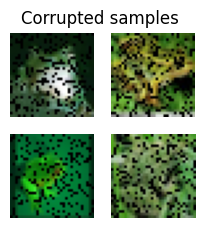

In [15]:
show_samples_image(data_part1, title="Samples part 1", N_samples=N_part1, grid_dim=4)
show_samples_image(data_part2, title="Samples part 2", N_samples=N_part2, grid_dim=2)
show_samples_image(corrupted_data, title="Corrupted samples", N_samples=N_part2, grid_dim=2) 

## 2. Project

## Q2.(ii) - Find $Q_{\bot}$ basis

In [16]:
# Q = [1_n | I_n]
Q = np.zeros((n, n+1))
Q[:, 0]  = np.ones(n)
Q[:, 1:] = np.eye(n)

# Compute QR decomposition
Q, _ = np.linalg.qr(Q)
Q = Q[:, 1:]

# Check the basis is correct
# Should give ≈ 0
for i in range(n-1):
    print(np.ones(n)@Q[:, i])


-1.5332179970073412e-13
1.7708057242771247e-14
1.2434497875801753e-14
2.298161660974074e-14
8.215650382226158e-15
-1.4765966227514582e-14
2.220446049250313e-15
1.0547118733938987e-14
-1.865174681370263e-14
-1.5265566588595902e-14
1.1213252548714081e-14
-8.326672684688674e-16
-2.220446049250313e-14
4.9404924595819466e-15
1.354472090042691e-14
0.0
-2.3425705819590803e-14
6.827871601444713e-15
-8.659739592076221e-15
1.7541523789077473e-14
7.882583474838611e-15
-1.3988810110276972e-14
1.8096635301390052e-14
5.9396931817445875e-15
1.9984014443252818e-14
2.0039525594484076e-14
1.609823385706477e-14
-4.9404924595819466e-15
8.881784197001252e-15
-1.5432100042289676e-14
-1.8984813721090177e-14
1.3911094498553211e-13
-3.774758283725532e-15
2.248201624865942e-14
-1.7763568394002505e-15
-6.938893903907228e-15
4.773959005888173e-15
-1.9984014443252818e-15
1.0436096431476471e-14
2.3370194668359545e-14
8.992806499463768e-15
9.2148511043888e-15
-1.27675647831893e-14
9.547918011776346e-15
1.47659662275

## Question 3  - Solve graph learning problem using Pymanopt

In [ ]:
def solve_graph_learning(channel: str, 
                         method: str, 
                         k: int) -> pymanopt.optimizers.optimizer.OptimizerResult:
    """Solve the graph learning problem (3) using Pymanopt on the Sphere manifold.

    Minimizes  tr(X^T (Q_perp M)(Q_perp M)^T X)  s.t. vec(M) in S^{(n-1)k - 1}

    Args:
        channel (str): Color channel to learn the graph for. One of 'R', 'G', 'B'.
        method (str): Optimizer to use. One of 'SteepestDescent', 'TrustRegions'.
        k (int): Rank of the Laplacian factorization. Must be < n.

    Returns:
        OptimizerResult with fields: point (M*), cost, iterations, log, ...
        The log['iterations']['cost'] list contains the cost at each iteration.
    """

    # Check arguments validity
    valid_channels = {'R', 'G', 'B'}
    if channel not in valid_channels:
        raise ValueError("channel must be one of %r." % valid_channels)

    valid_methods = {'SteepestDescent', 'TrustRegions'}
    if method not in valid_methods:
        raise ValueError("method must be one of %r." % valid_methods)
    
    if not k < n:
        raise ValueError("k must be less than n=%d" % n)

    # Data matrix for the chosen channel
    X = data_part1[:, channel_idx[channel], :]          # (n, N_part1)

    # Precompute S = Q^T X X^T Q  (size (n-1) x (n-1)) 
    A = Q.T @ X          # (n-1, N_part1)
    S = A @ A.T           # (n-1, n-1)

    # Manifold: unit Frobenius-norm matrices of size (n-1) x k 
    manifold = Sphere(n - 1, k)

    # Track cost at each evaluation (workaround: TrustRegions in pymanopt
    # 2.2.1 does not populate log['iterations'], so we record costs manually) 
    cost_history = []

    # Cost:  f(M) = tr(M^T S M) = sum_{ij} M_{ij} (S M)_{ij}
    @pymanopt.function.numpy(manifold)
    def cost(M):
        val = np.sum(M * (S @ M))
        cost_history.append(val)
        return val

    # Euclidean gradient:  grad f(M) = 2 S M 
    @pymanopt.function.numpy(manifold)
    def egrad(M):
        return 2 * S @ M

    # Euclidean Hessian:  Hess f(M)[V] = 2 S V 
    @pymanopt.function.numpy(manifold)
    def ehess(M, V):
        return 2 * S @ V

    # Pymanopt problem 
    problem = pymanopt.Problem(
        manifold=manifold,
        cost=cost,
        euclidean_gradient=egrad,
        euclidean_hessian=ehess,
    )

    # Optimizer 
    if method == 'SteepestDescent':
        optimizer = SteepestDescent(max_iterations=100, log_verbosity=2, verbosity=2)
    else:
        optimizer = TrustRegions(max_iterations=100, log_verbosity=2, verbosity=2)

    # Solve 
    result = optimizer.run(problem)

    # Patch missing iteration log for TrustRegions 
    if not result.log['iterations'].get('cost'):
        result.log['iterations']['cost'] = cost_history

    return result

In [24]:
# Run Q3 experiments: all channels × {SteepestDescent, TrustRegions} × {k=n-1, k=30}
results_q3 = {}

for channel in ['R', 'G', 'B']:
    for method in ['SteepestDescent', 'TrustRegions']:
        for k in [n - 1, 30]:
            key = (channel, method, k)
            print(f"Solving: channel={channel}, method={method}, k={k} ...")
            results_q3[key] = solve_graph_learning(channel, method, k)
            res = results_q3[key]
            print(f"  → cost = {res.cost:.6f}, iterations = {res.iterations}, "
                  f"time = {res.time:.2f}s\n")

Solving: channel=R, method=SteepestDescent, k=1023 ...
Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
  1          +7.5658625564500932e+00    1.41172233e+02    
  2          +4.5614896035662538e+00    8.60280547e+01    
  3          +3.3924327762587372e+00    4.98159283e+01    
  4          +2.8720483009384612e+00    3.87734752e+01    
  5          +2.6102242900442034e+00    4.94989541e+01    
  6          +2.2541389506411980e+00    3.24220919e+01    
  7          +2.1471535187903514e+00    4.31274718e+01    
  8          +1.8761585340361613e+00    1.69866268e+01    
  9          +1.6241810820775120e+00    3.67188500e+01    
 10          +1.4336849988844735e+00    1.77329987e+01    
 11          +1.3689518412882280e+00    2.00393032e+01    
 12          +1.3305540303545609e+00    2.56072105e+01    
 13          +1.2332257019592507e+00    1.05386958e+01    
 14          +1.1073213877309671e+00    3.7431

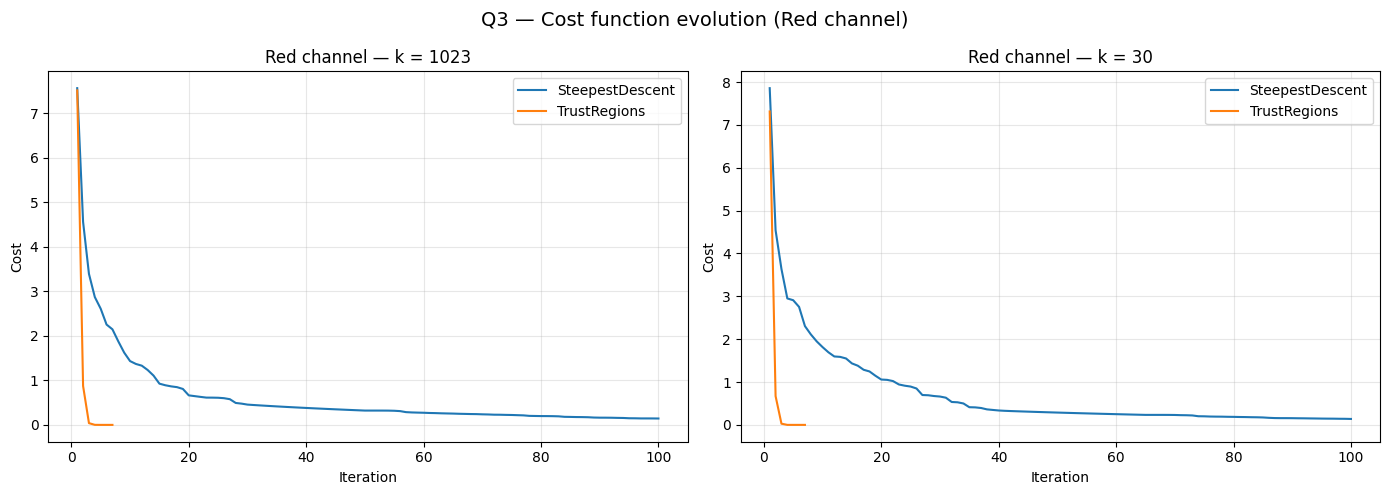

In [37]:
# Plot cost evolution for the RED channel (both methods, both k values)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, k in enumerate([n - 1, 30]):
    ax = axes[i]
    for method in ['SteepestDescent', 'TrustRegions']:
        key = ('R', method, k)
        costs = results_q3[key].log['iterations']['cost']
        ax.plot(range(1, len(costs) + 1), costs, label=method)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost')
    ax.set_title(f'Red channel — k = {k}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Q3 — Cost function evolution (Red channel)', fontsize=14)
plt.tight_layout()
plt.savefig("figures/q3_cost_evolution_red_channel.svg", bbox_inches="tight")
plt.show()

In [26]:
# Extract the learned Laplacian representations M^(c) for later use (k=30, TrustRegions)
# The Laplacian is recovered as:  L^(c) = n * (Q @ M^(c)) @ (Q @ M^(c))^T

M_learned = {}
L_learned = {}

for channel in ['R', 'G', 'B']:
    key = (channel, 'TrustRegions', 30)
    M_c = results_q3[key].point                # (n-1, 30)
    M_learned[channel] = M_c
    L_learned[channel] = n * (Q @ M_c) @ (Q @ M_c).T   # (n, n)
    
    # Sanity checks
    L = L_learned[channel]
    print(f"Channel {channel}:")
    print(f"  L shape      = {L.shape}")
    print(f"  L @ 1_n ≈ 0  : max|L @ 1_n| = {np.max(np.abs(L @ np.ones(n))):.2e}")
    print(f"  tr(L)   ≈ n  : tr(L) = {np.trace(L):.4f}")
    print(f"  L ⪰ 0        : min eigenvalue = {np.linalg.eigvalsh(L)[0]:.2e}")
    print(f"  rank(L) ≤ 30 : rank = {np.linalg.matrix_rank(L, tol=1e-8)}")
    print()

Channel R:
  L shape      = (1024, 1024)
  L @ 1_n ≈ 0  : max|L @ 1_n| = 2.06e-13
  tr(L)   ≈ n  : tr(L) = 1024.0000
  L ⪰ 0        : min eigenvalue = -2.49e-14
  rank(L) ≤ 30 : rank = 30

Channel G:
  L shape      = (1024, 1024)
  L @ 1_n ≈ 0  : max|L @ 1_n| = 1.50e-13
  tr(L)   ≈ n  : tr(L) = 1024.0000
  L ⪰ 0        : min eigenvalue = -2.18e-14
  rank(L) ≤ 30 : rank = 30

Channel B:
  L shape      = (1024, 1024)
  L @ 1_n ≈ 0  : max|L @ 1_n| = 1.91e-13
  tr(L)   ≈ n  : tr(L) = 1024.0000
  L ⪰ 0        : min eigenvalue = -2.34e-14
  rank(L) ≤ 30 : rank = 30



## Question 4 — Time complexity vs rank $k$

In [30]:
import time

def time_single_iteration_sd(channel: str, k: int, n_repeats: int = 5) -> float:
    """Time a single SteepestDescent iteration for a given rank k.
    
    Runs 1 iteration, repeats n_repeats times and returns the median time.
    """
    X = data_part1[:, channel_idx[channel], :]
    A = Q.T @ X
    S = A @ A.T

    manifold = Sphere(n - 1, k)

    @pymanopt.function.numpy(manifold)
    def cost(M):
        return np.sum(M * (S @ M))

    @pymanopt.function.numpy(manifold)
    def egrad(M):
        return 2 * S @ M

    problem = pymanopt.Problem(manifold=manifold, cost=cost, euclidean_gradient=egrad)

    times = []
    for _ in range(n_repeats):
        optimizer = SteepestDescent(max_iterations=1, verbosity=0)
        t0 = time.perf_counter()
        optimizer.run(problem)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    
    return np.median(times)

# Test a range of k values
k_values = np.unique(np.concatenate([
    np.arange(1, 20),
    np.arange(20, 101, 10),
    np.arange(100, n, 100),
    [n - 1]
])).astype(int)

print(f"Testing {len(k_values)} values of k from {k_values[0]} to {k_values[-1]}...")

times_per_k = []
for k_val in k_values:
    t = time_single_iteration_sd('R', k_val)
    times_per_k.append(t)
    print(f"  k = {k_val:4d}  →  {t*1000:.2f} ms")

times_per_k = np.array(times_per_k)

Testing 38 values of k from 1 to 1023...
  k =    1  →  1.45 ms
  k =    2  →  2.80 ms
  k =    3  →  4.78 ms
  k =    4  →  3.25 ms
  k =    5  →  3.64 ms
  k =    6  →  3.90 ms
  k =    7  →  6.05 ms
  k =    8  →  3.77 ms
  k =    9  →  3.97 ms
  k =   10  →  3.79 ms
  k =   11  →  6.60 ms
  k =   12  →  5.29 ms
  k =   13  →  6.09 ms
  k =   14  →  5.80 ms
  k =   15  →  5.56 ms
  k =   16  →  5.78 ms
  k =   17  →  6.14 ms
  k =   18  →  7.12 ms
  k =   19  →  45.76 ms
  k =   20  →  6.21 ms
  k =   30  →  8.76 ms
  k =   40  →  7.85 ms
  k =   50  →  9.42 ms
  k =   60  →  12.56 ms
  k =   70  →  11.94 ms
  k =   80  →  14.79 ms
  k =   90  →  17.72 ms
  k =  100  →  34.39 ms
  k =  200  →  34.19 ms
  k =  300  →  58.44 ms
  k =  400  →  73.50 ms
  k =  500  →  89.54 ms
  k =  600  →  93.44 ms
  k =  700  →  125.13 ms
  k =  800  →  129.87 ms
  k =  900  →  137.19 ms
  k = 1000  →  172.49 ms
  k = 1023  →  164.41 ms


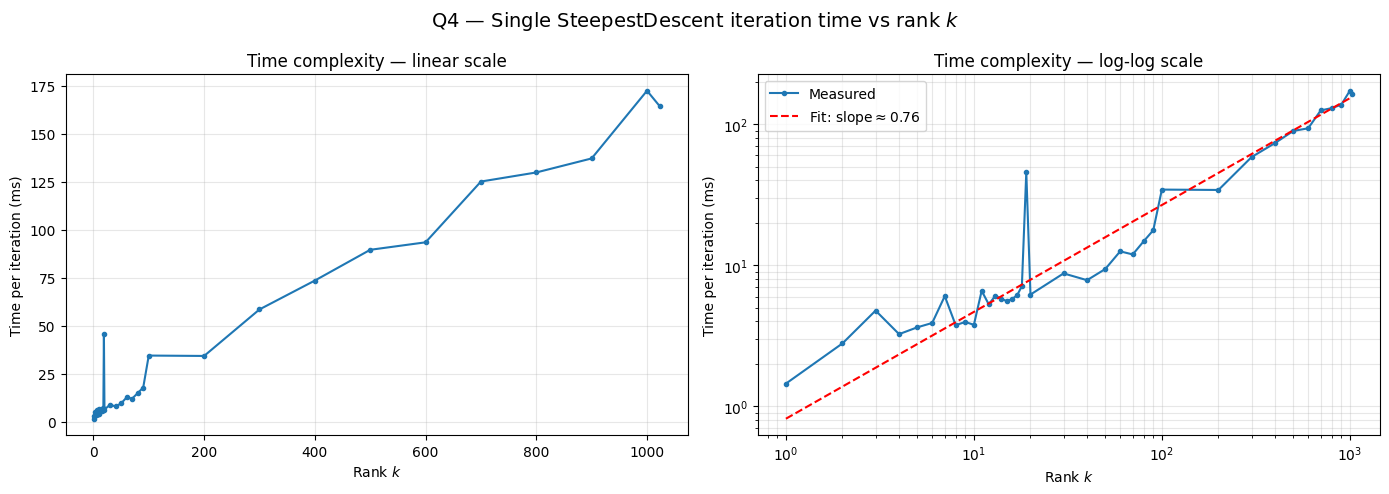


Fitted power law exponent: α = 0.76
Expected: α = 1 (cost & gradient are dominated by S @ M, which is O(n²·k))


In [63]:
# Plot time per iteration vs k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale
ax = axes[0]
ax.plot(k_values, times_per_k * 1000, 'o-', markersize=3)
ax.set_xlabel('Rank $k$')
ax.set_ylabel('Time per iteration (ms)')
ax.set_title('Time complexity — linear scale')
ax.grid(True, alpha=0.3)

# Right: log-log scale to identify the polynomial order
ax = axes[1]
ax.loglog(k_values, times_per_k * 1000, 'o-', markersize=3, label='Measured')

# Fit a power law: time ∝ k^α  →  log(time) = α log(k) + const
log_k = np.log(k_values.astype(float))
log_t = np.log(times_per_k)
mask = k_values >= 100
alpha_large, intercept_large = np.polyfit(np.log(k_values[mask].astype(float)), 
                                           np.log(times_per_k[mask]), 1)
ax.loglog(k_values, np.exp(intercept_large) * k_values**alpha_large * 1000, '--', 
          label=rf'Fit: slope$\approx {alpha_large:.2f}$', color='red')
ax.set_xlabel('Rank $k$')
ax.set_ylabel('Time per iteration (ms)')
ax.set_title('Time complexity — log-log scale')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Q4 — Single SteepestDescent iteration time vs rank $k$', fontsize=14)
plt.tight_layout()
plt.savefig("figures/q4_time_complexity_sd_iteration.svg", bbox_inches="tight")
plt.show()

print(f"\nFitted power law exponent: α = {alpha_large:.2f}")
print(f"Expected: α = 1 (cost & gradient are dominated by S @ M, which is O(n²·k))")

## Question 5 — Custom retractions on the Sphere

In [52]:
class SphereNewRetraction(Sphere):
    """Sphere manifold with the retraction from Exercise 3:
        R_v^new(x) = x * (4 - ||v||^2) / (4 + ||v||^2) + v * 4 / (4 + ||v||^2)
    """
    def retraction(self, point, tangent_vector):
        nv2 = np.linalg.norm(tangent_vector)**2
        return point * (4 - nv2) / (4 + nv2) + tangent_vector * 4 / (4 + nv2)


class SphereWrongRetraction(Sphere):
    """Sphere manifold with a WRONG retraction: R_v^wrong(x) = x + v
    (does not map back to the sphere)
    """
    def retraction(self, point, tangent_vector):
        return point + tangent_vector

In [80]:
def solve_graph_learning_custom_retraction(channel: str, k: int, 
                                           manifold_class, retraction_label: str,
                                           max_iterations: int = 100):
    """Run SteepestDescent on the graph learning problem with a custom Sphere manifold."""
    
    X = data_part1[:, channel_idx[channel], :]
    A = Q.T @ X
    S = A @ A.T

    manifold = manifold_class(n - 1, k)

    @pymanopt.function.numpy(manifold)
    def cost(M):
        return np.sum(M * (S @ M))

    @pymanopt.function.numpy(manifold)
    def egrad(M):
        return 2 * S @ M

    problem = pymanopt.Problem(manifold=manifold, cost=cost, euclidean_gradient=egrad)
    optimizer = SteepestDescent(max_iterations=max_iterations, log_verbosity=2, verbosity=0)

    result = optimizer.run(problem)
    return result


# Run experiments: Red channel, k=30, all 3 retractions
retraction_configs = [
    (Sphere,                "Default: $(x+v)/\\|x+v\\|$"),
    (SphereNewRetraction,   "New: $x \\frac{4 - ||v||^2}{4 + ||v||^2} + v \\frac{4}{4 + ||v||^2}$"),
    (SphereWrongRetraction, "Wrong: $x + v$"),
]

results_q5 = {}
for manifold_class, label in retraction_configs:
    print(f"Running: {label} ...")
    try:
        res = solve_graph_learning_custom_retraction('R', k=30, 
                                                      manifold_class=manifold_class,
                                                      retraction_label=label)
        results_q5[label] = res
        print(f"  → cost = {res.cost:.6f}, iterations = {res.iterations}, "
              f"  stopping: {res.stopping_criterion}\n")
    except Exception as e:
        print(f"  → FAILED: {e}\n")
        results_q5[label] = None

Running: Default: $(x+v)/\|x+v\|$ ...
  → cost = 0.116551, iterations = 100,   stopping: Terminated - max iterations reached after 1.42 seconds.

Running: New: $x \frac{4 - ||v||^2}{4 + ||v||^2} + v \frac{4}{4 + ||v||^2}$ ...
  → cost = 0.159659, iterations = 100,   stopping: Terminated - max iterations reached after 0.48 seconds.

Running: Wrong: $x + v$ ...
  → cost = 0.091819, iterations = 100,   stopping: Terminated - max iterations reached after 0.47 seconds.



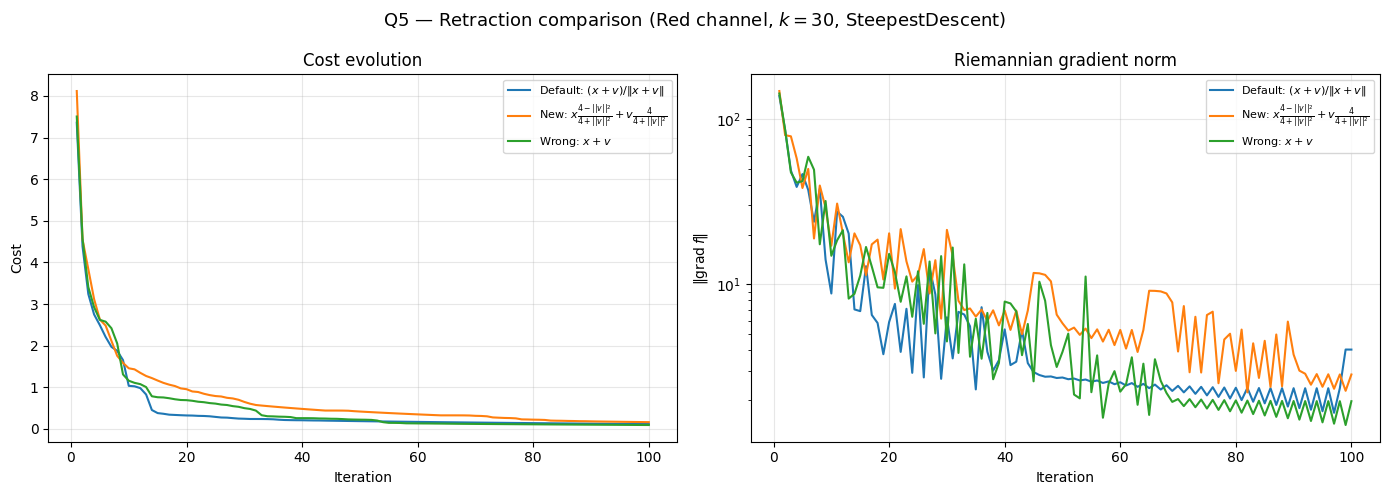

In [81]:
# Plot cost evolution and gradient norm for all 3 retractions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, res in results_q5.items():
    if res is None:
        continue
    costs = res.log['iterations']['cost']
    grad_norms = res.log['iterations']['gradient_norm']
    iters = range(1, len(costs) + 1)
    
    axes[0].plot(iters, costs, label=label)
    axes[1].plot(range(1, len(grad_norms) + 1), grad_norms, label=label)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost evolution')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('$\\|\\mathrm{grad}\\, f\\|$')
axes[1].set_title('Riemannian gradient norm')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.suptitle('Q5 — Retraction comparison (Red channel, $k=30$, SteepestDescent)', fontsize=13)
plt.tight_layout()
plt.savefig("figures/q5_retraction_comparison.svg", bbox_inches="tight")
plt.show()

In [82]:
# Verify: does each retraction stay on the sphere?
# Check ||M*||_F for the final point of each retraction
print("Final point Frobenius norm (should be 1.0 for valid retractions):\n")
for label, res in results_q5.items():
    if res is None:
        print(f"  {label}: FAILED (no result)")
        continue
    norm_M = np.linalg.norm(res.point)
    print(res.point.shape)
    print(f"  {label}:")
    print(f"    ||M*||_F = {norm_M:.10f}")
    print(f"    Final cost = {res.cost:.6e}")
    print(f"    Iterations = {res.iterations}")
    print(f"    Stopping: {res.stopping_criterion}")
    print()

Final point Frobenius norm (should be 1.0 for valid retractions):

(1023, 30)
  Default: $(x+v)/\|x+v\|$:
    ||M*||_F = 1.0000000000
    Final cost = 1.165515e-01
    Iterations = 100
    Stopping: Terminated - max iterations reached after 1.42 seconds.

(1023, 30)
  New: $x \frac{4 - ||v||^2}{4 + ||v||^2} + v \frac{4}{4 + ||v||^2}$:
    ||M*||_F = 1.0000000000
    Final cost = 1.596592e-01
    Iterations = 100
    Stopping: Terminated - max iterations reached after 0.48 seconds.

(1023, 30)
  Wrong: $x + v$:
    ||M*||_F = 1.0111220142
    Final cost = 9.181870e-02
    Iterations = 100
    Stopping: Terminated - max iterations reached after 0.47 seconds.

